*****1. Introduction*****

***1.1 Dataset Description:***

The Credit Risk Dataset is a collection of financial and demographic data used to determine creditworthiness. It contains 32,581 instances and 12 features.

***1.2 Domain Motivation:***

The primary goal is to minimize default risk by identifying patterns in applicant behavior. This analysis serves as the foundation for Clustering and Fuzzy Logic systems designed to automate loan approval decisions.

*****Data Collection & Audit*****

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#  Load the dataset
df = pd.read_csv('credit_risk_dataset.csv')

# Initial Audit
print(f"Dataset Shape: {df.shape}")
print("\n--- Data Types ---")
print(df.info())

print("\n--- Missing Values Summary ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\n--- Total Duplicate Rows: {df.duplicated().sum()} ---")

print("\n--- Descriptive Statistics ---")
display(df.describe())

Dataset Shape: (32581, 12)

--- Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


***Exploratory Data Analysis (Visualizations)***

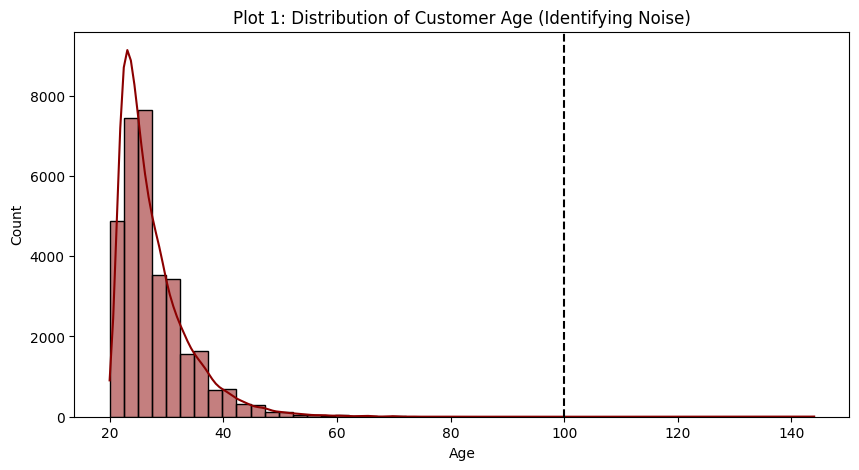

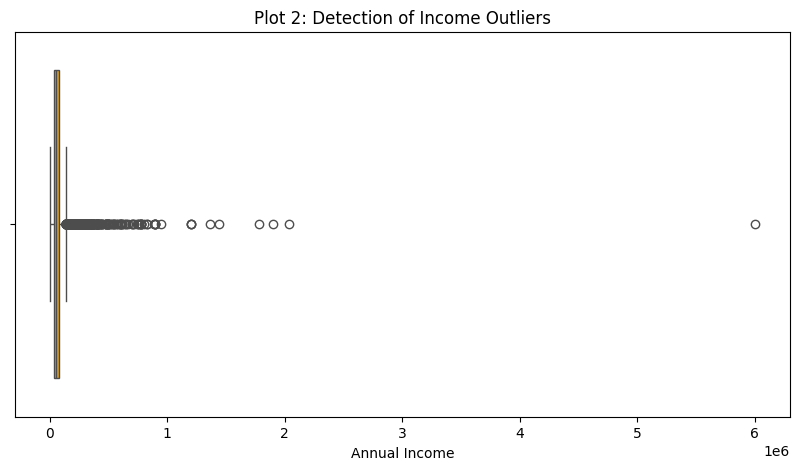

C:\Users\Mega Store\AppData\Local\Temp\ipykernel_46264\2448603551.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='loan_intent', order=order, palette='viridis')


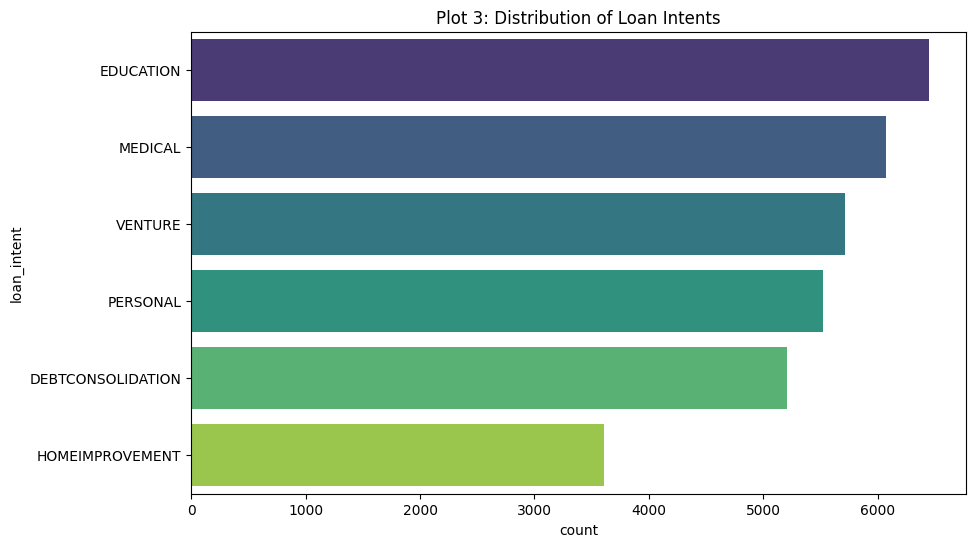

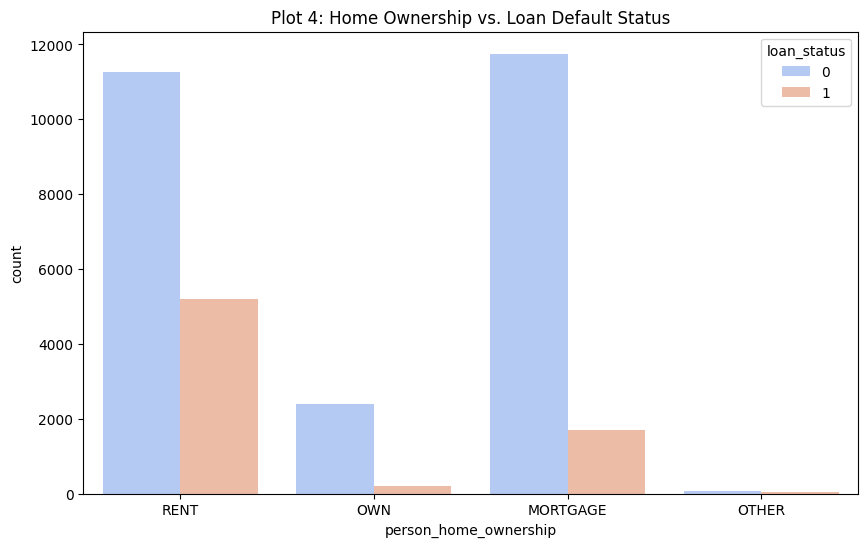

C:\Users\Mega Store\AppData\Local\Temp\ipykernel_46264\2448603551.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loan_grade', y='loan_int_rate', order=['A','B','C','D','E','F','G'], palette='muted')


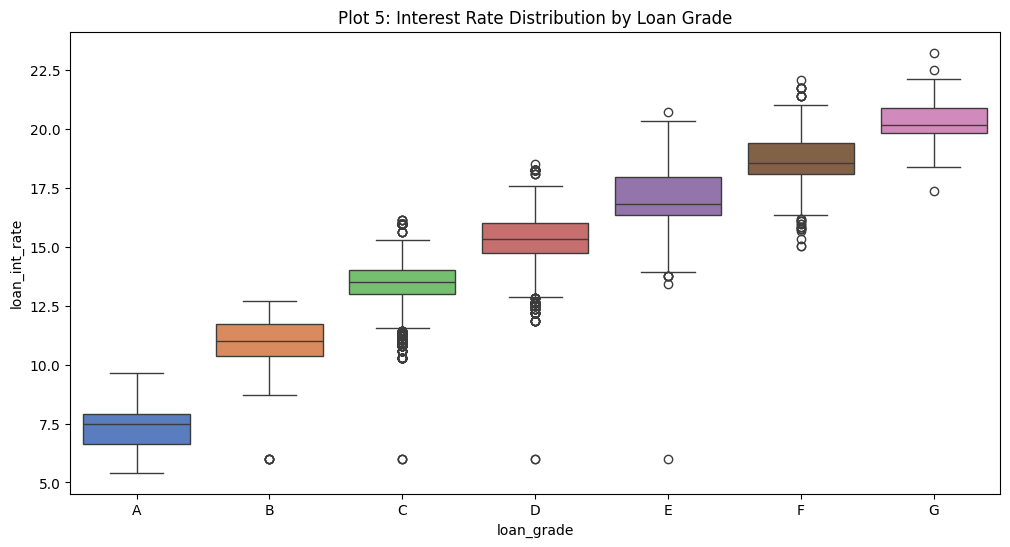

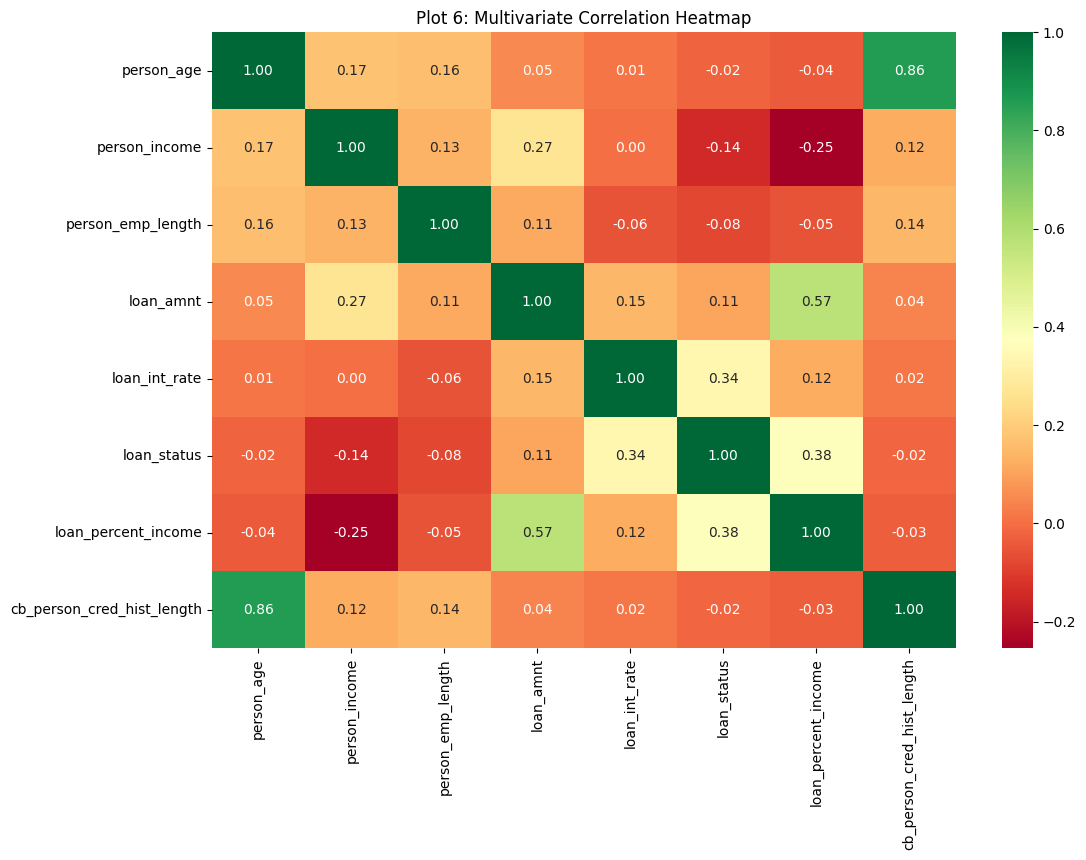

In [2]:
#  Distribution of Customer Age (Noise Identification)
plt.figure(figsize=(10, 5))
sns.histplot(df['person_age'], bins=50, kde=True, color='darkred')
plt.axvline(100, color='black', linestyle='--')
plt.title('Plot 1: Distribution of Customer Age (Identifying Noise)')
plt.xlabel('Age')
plt.show()

#  Detection of Income Outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['person_income'], color='orange')
plt.title('Plot 2: Detection of Income Outliers')
plt.xlabel('Annual Income')
plt.show()

# Loan Intent Frequency
plt.figure(figsize=(10, 6))
order = df['loan_intent'].value_counts().index
sns.countplot(data=df, y='loan_intent', order=order, palette='viridis')
plt.title('Plot 3: Distribution of Loan Intents')
plt.show()

# Home Ownership vs. Loan Status
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='person_home_ownership', hue='loan_status', palette='coolwarm')
plt.title('Plot 4: Home Ownership vs. Loan Default Status')
plt.show()

#  Interest Rate Distribution by Loan Grade
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='loan_grade', y='loan_int_rate', order=['A','B','C','D','E','F','G'], palette='muted')
plt.title('Plot 5: Interest Rate Distribution by Loan Grade')
plt.show()

#  Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Plot 6: Multivariate Correlation Heatmap')
plt.show()